# Category-level structural fingerprinting

10 categories × 5 assets each (50 total). Goal: characterise the **category-level** structure (not individual asset alpha) and find the structural patterns linking categories.

Pipeline implemented in `cluster_analysis.py`. This notebook calls each phase, renders the results, and (in Phase 3) prints the auto-generated falsifiable hypotheses populated with real numbers from your data.

**Run order.** Either:

1. `python cluster_analysis.py` — runs everything, saves to `results_clusters/<run_id>/`. Then this notebook just *loads* and visualises.
2. Or call `ca.run_full_analysis()` directly from the cell below — same result, returned in-memory. Useful for iterating.

Either way, every numeric claim below comes from `meta.json` or a parquet in the run directory.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram

import cluster_analysis as ca
from io_results import list_runs, load_run, make_run_id, save_run

plt.rcParams['figure.dpi'] = 110
RESULTS_DIR = 'results_clusters'

## Run (or load) the analysis

If a run directory already exists under `results_clusters/`, this loads the latest. Otherwise it runs the pipeline once and saves it.

In [2]:
runs = list_runs(RESULTS_DIR)
if not runs:
    print('no existing runs — executing pipeline')
    out = ca.run_full_analysis()
    save_run(RESULTS_DIR, out['artifacts'], meta=out['meta'], run_id=make_run_id())
    runs = list_runs(RESULTS_DIR)

res = load_run(RESULTS_DIR, run_id=runs[0])
meta = res['_meta']
print('loaded:', res['_run_id'])
print('T =', meta['T'], '  N_categories =', meta['n_categories'],
      '  N_assets =', meta['n_assets_total'])
print('features:', meta['features'])

loaded: 20260430_025911
T = 30000   N_categories = 10   N_assets = 50
features: ['trend_slope', 'vol_mean', 'vol_of_vol', 'acf_1', 'acf_5', 'acf_20', 'hurst', 'max_dd', 'skew', 'xs_kurt', 'intra_corr']


---
## Phase 1 — Structural fingerprint per category

Each category is summarised by an 11-dim vector. Per-asset features are aggregated to category level by **median** (chosen over mean: robust to a single outlier asset within a category, which is a real risk with 5-asset categories).

**The 11 features**

| feature | what it captures | computed how |
|---|---|---|
| `trend_slope` | long-run drift in log-price | OLS slope of log(price) on `t`, divided by mean log-price |
| `vol_mean` | typical realised vol | mean of rolling-std (window=200) of log-returns |
| `vol_of_vol` | stability of the vol regime | std of the same rolling-std series |
| `acf_1`, `acf_5`, `acf_20` | persistence at three horizons | sample ACF of log-returns |
| `hurst` | mean-reversion vs. trending | R/S Hurst exponent on log-prices: H<0.5 = MR, H>0.5 = trend |
| `max_dd` | tail risk profile | largest peak-to-trough drawdown |
| `skew`, `xs_kurt` | distributional shape | sample skew, excess kurtosis of log-returns |
| `intra_corr` | within-category cohesion | mean of off-diagonal entries of the 5×5 return-correlation matrix |

Pruned: ADF statistic (redundant with Hurst for this purpose; both test the unit-root vs. mean-reversion axis).

In [3]:
fp = res['fingerprint_raw']
fpz = res['fingerprint_zscore']
fp.round(3)

,trend_slope,vol_mean,vol_of_vol,acf_1,acf_5,acf_20,hurst,max_dd,skew,xs_kurt,intra_corr
category,,,,,,,,,,,
GALAXY,0.0,0.001,0.0,-0.012,0.002,0.002,0.533,0.151,0.003,0.008,0.004
MICROCHIP,-0.0,0.001,0.0,-0.007,0.000,-0.002,0.510,0.287,0.002,0.016,0.006
OXYGEN,0.0,0.001,0.0,-0.005,0.002,-0.004,0.518,0.196,0.012,0.006,0.007
PANEL,-0.0,0.001,0.0,-0.002,-0.001,0.001,0.535,0.233,-0.004,-0.015,0.004
PEBBLES,0.0,0.002,0.0,0.007,0.010,-0.007,0.514,0.239,0.004,0.104,-0.191
ROBOT,-0.0,0.001,0.0,-0.012,-0.001,-0.005,0.519,0.200,0.009,0.019,-0.001
SLEEP,0.0,0.001,0.0,-0.001,0.005,0.004,0.519,0.153,-0.006,-0.009,0.003
SNACKPACK,0.0,0.001,0.0,-0.025,0.002,0.001,0.510,0.091,-0.002,-0.009,-0.160
TRANSLATOR,0.0,0.001,0.0,-0.007,0.002,-0.001,0.516,0.158,-0.010,0.008,0.004


**Heatmap of the z-scored fingerprint.** Each cell shows how many standard deviations the category sits above (blue) or below (red) the cross-category mean for that feature. Reading rules:

- **Bright row** (mostly one color) = the category is structurally extreme on many dimensions; a candidate archetype anchor.
- **Bright column** = the feature has high cross-category dispersion; it carries discriminative information.
- **Pale column** = feature varies little between categories; downweight when interpreting.

**Sensitivity flag.** The `vol_window=200` and the choice to use the **median** vs. mean for category aggregation both affect the fingerprint magnitudes. The `meta['vol_window']` field records the value used; re-run with a different value to bound robustness.

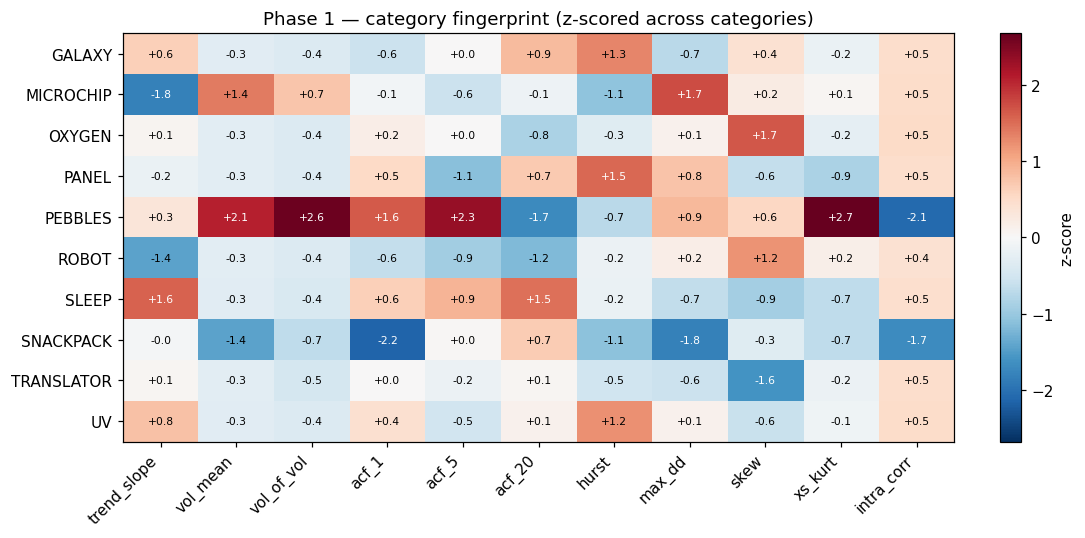

In [4]:
M = fpz.values
vlim = float(np.nanmax(np.abs(M)))
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(M, cmap='RdBu_r', vmin=-vlim, vmax=vlim, aspect='auto')
ax.set_xticks(range(fpz.shape[1])); ax.set_xticklabels(fpz.columns, rotation=45, ha='right')
ax.set_yticks(range(fpz.shape[0])); ax.set_yticklabels(fpz.index)
for i in range(fpz.shape[0]):
    for j in range(fpz.shape[1]):
        v = M[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > vlim*0.55 else 'black')
plt.colorbar(im, ax=ax, label='z-score', fraction=0.04)
ax.set_title('Phase 1 — category fingerprint (z-scored across categories)')
plt.tight_layout(); plt.show()

---
## Phase 2a — Consistent dominance / underperformance

For each feature the categories are ranked 1..10 (10 = highest value). For each category we count how many features it sits in the **top-2** vs **bottom-2**. A category with `n_top2 ≥ 4` or `n_bot2 ≥ 4` is a structural outlier in the sense the prompt asks about.

**How to read.**

- `mean_rank` near 5.5 = the category is structurally *average* across features.
- High `n_top2` and high `n_bot2` simultaneously = the category is **extreme on many features but mixed-direction** — interesting but not a clean archetype.
- High `rank_std` = inconsistent across features (e.g. trends one way on vol, opposite on persistence). Useful for ruling categories out as archetype anchors.

**Caveat.** Rank-based dominance ignores effect size; a category that's #1 by 0.001 counts the same as #1 by 1.0σ. Cross-check the `dominance_summary` table against the z-score heatmap for any close calls.

In [5]:
summary = res['dominance_summary']
summary.round(2)

,mean_rank,rank_std,n_top2,n_bot2
category,,,,
PEBBLES,7.18,3.71,6,2
OXYGEN,6.36,2.25,2,0
UV,6.18,1.78,1,0
MICROCHIP,5.91,3.24,4,2
GALAXY,5.82,2.44,2,1
PANEL,5.73,3.17,1,2
SLEEP,5.55,3.33,4,2
ROBOT,4.91,2.91,2,4
TRANSLATOR,4.36,1.57,0,2


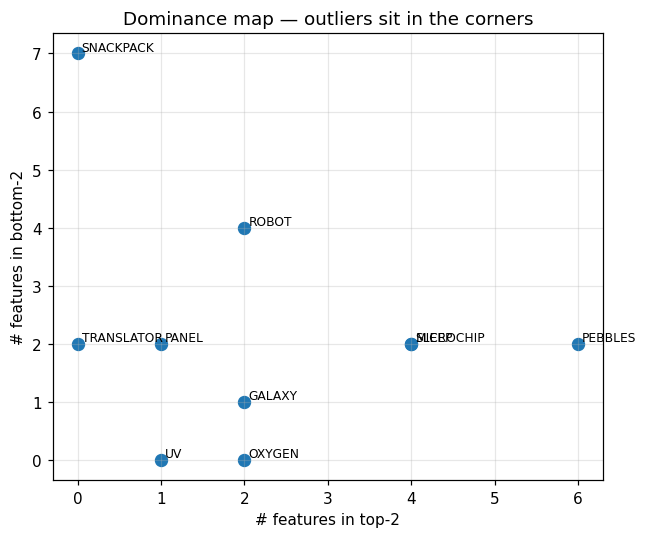

In [6]:
# Visual: dot plot of (n_top2, n_bot2) per category.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(summary['n_top2'], summary['n_bot2'], s=60, color='#1f77b4')
for cat, row in summary.iterrows():
    ax.annotate(cat, (row['n_top2']+0.05, row['n_bot2']+0.05), fontsize=8)
ax.set_xlabel('# features in top-2'); ax.set_ylabel('# features in bottom-2')
ax.set_title('Dominance map — outliers sit in the corners')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Phase 2b — Co-movement and divergence

**Index construction.** For each category we form an equal-weight, normalized price index (each asset divided by its first valid observation, then averaged across the 5 assets). All Pearson correlations below are computed on **log-returns** of those indices, not on price levels (using levels would inflate correlation through shared trend).

**Three lenses:**

1. **Full-sample correlation** — the headline number. Symmetric, on-diagonal = 1, sign matters.
2. **Half-sample correlations** — same metric on the first vs. second half. Pairs whose correlation flips sign across halves go to the `sign_flip_pairs` table.
3. **Sign-flip pairs** — the cleanest evidence of regime-conditional comovement. A pair listed there is one whose link cannot be summarised by a single number.

**How to read.**

- |corr| > 0.5 between two category indices is a strong claim — many shared inputs or a common driver.
- |corr| < 0.05 = effectively independent at the chosen sampling rate.
- A row of consistently moderate correlations (~0.2–0.3) with most others = a *broad-market* category; very few correlations with any specific peer = an idiosyncratic category.

**Sensitivity flag.** Splitting the sample at the midpoint is the simplest regime split but arbitrary. The auto-emitted hypotheses only flag pairs whose sign actually flips (a strong condition); pairs with merely changing magnitudes won't appear here. To stress-test: increase `n_corr_splits` in the driver.

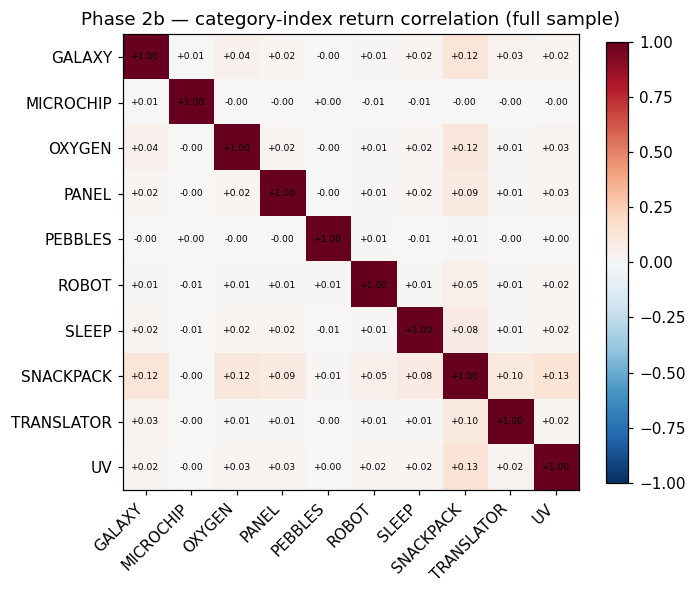

In [7]:
corr_full = res['corr_full']
vlim = float(np.abs(corr_full.values - np.eye(len(corr_full))).max())
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr_full.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_full))); ax.set_xticklabels(corr_full.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_full))); ax.set_yticklabels(corr_full.index)
for i in range(len(corr_full)):
    for j in range(len(corr_full)):
        ax.text(j, i, f'{corr_full.values[i,j]:+.2f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Phase 2b — category-index return correlation (full sample)')
plt.tight_layout(); plt.show()

In [8]:
# Sign-flipping pairs (regime-conditional comovement)
flips = res.get('sign_flip_pairs')
if flips is None or flips.empty:
    print('No sign-flipping pairs at the current split granularity.')
else:
    print(f'{len(flips)} pairs flip sign across the {meta["n_corr_splits"]} time slices')
    flips.round(3)

10 pairs flip sign across the 2 time slices


---
## Phase 2c — Threshold-conditional behaviour

For each category index we split time into **low-vol** vs **high-vol** halves (split at the median of the rolling-std), recompute the fingerprint inside each, and report the L1 distance per (category, feature). High-deviation cells = the category's structure is *regime-dependent* on its own volatility.

**How to read.**

- A category with high `mean_abs_delta` is one whose autocorrelation / drift / shape is *not stable* once you condition on its own vol regime. Treat its full-sample fingerprint as an average of two distinct regimes.
- If `max_abs_delta_feature == 'acf_1'` is common, then the persistence structure is the most regime-sensitive aspect — useful when designing momentum vs. mean-reversion signals.
- Categories at the bottom of this list are the ones whose fingerprint *truly* generalises.

**Sensitivity flag.** Splitting at the median vol is arbitrary; quartile splits would surface different patterns. The current split was chosen because it guarantees both regimes have ≥ T/2 observations, keeping the per-regime fingerprint estimable.

In [9]:
rs = res['regime_stability_summary']
rs.round(3)

,mean_abs_delta,max_abs_delta_feature,max_abs_delta_value
ROBOT,12.819,xs_kurt,136.714
PEBBLES,6.127,xs_kurt,64.238
UV,5.317,xs_kurt,56.782
OXYGEN,4.731,xs_kurt,51.282
PANEL,4.284,xs_kurt,46.255
TRANSLATOR,4.192,xs_kurt,44.978
SNACKPACK,4.076,xs_kurt,43.754
GALAXY,2.985,xs_kurt,30.341
SLEEP,1.987,xs_kurt,19.901
MICROCHIP,0.704,xs_kurt,7.677


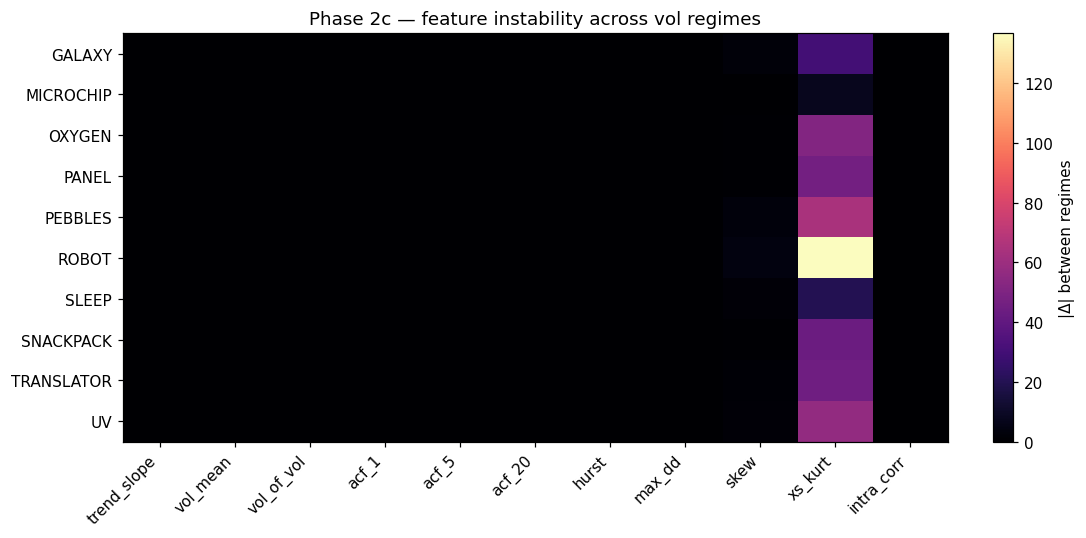

In [10]:
# Heatmap of |fingerprint(high-vol) - fingerprint(low-vol)|
delta = res['regime_delta']
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(delta.values, cmap='magma', aspect='auto')
ax.set_xticks(range(delta.shape[1])); ax.set_xticklabels(delta.columns, rotation=45, ha='right')
ax.set_yticks(range(delta.shape[0])); ax.set_yticklabels(delta.index)
plt.colorbar(im, ax=ax, fraction=0.04, label='|Δ| between regimes')
ax.set_title('Phase 2c — feature instability across vol regimes')
plt.tight_layout(); plt.show()

---
## Phase 2d — Temporal drift

The data is split into 4 equal time windows; the fingerprint is recomputed in each, and `drift_distance` reports the L2 distance (in the per-window z-score space) between consecutive windows per category.

**Two diagnostics:**

1. **`drift_distance`** — total trajectory length per category. Top of the list = drifting; bottom = stable across the whole horizon.
2. **`pair_convergence`** — for every pair of categories, the change in pairwise distance between window 0 and window N (the last). Most negative `delta` = pair is *converging* over time; most positive = diverging.

**How to read.**

- A drifting category may simply be reacting to an exogenous regime change shared by everyone. Confirm by checking whether the drift trajectory direction is correlated across categories — a **common drift** is more interesting than a single-category drift, but means none of the pairwise comparisons in Phase 2b should be trusted as time-stationary.
- Convergence (Δdistance < 0) between two categories suggests they're becoming **structurally more similar** — possibly merging into a shared archetype.

**Caveat.** With 4 windows, drift estimates have very few degrees of freedom. Use them to *generate* hypotheses, not as point estimates.

In [11]:
drift = res['drift_distance']
drift.round(2)

,drift_w0_w1,drift_w1_w2,drift_w2_w3,mean_drift
category,,,,
PANEL,4.55,4.64,4.20,4.46
SLEEP,3.45,4.65,4.50,4.20
MICROCHIP,3.16,3.51,4.15,3.61
SNACKPACK,3.87,4.31,2.40,3.53
ROBOT,3.04,3.73,3.65,3.47
OXYGEN,3.41,3.51,3.27,3.40
UV,3.31,3.77,2.92,3.33
PEBBLES,4.14,2.90,2.78,3.28
GALAXY,3.37,3.48,1.71,2.85


In [12]:
# Top-5 converging and diverging pairs
pc = res['pair_convergence']
print('Top 5 CONVERGING pairs (Δ distance most negative):')
print(pc.head(5).round(3).to_string(index=False))
print('\nTop 5 DIVERGING pairs (Δ distance most positive):')
print(pc.tail(5).iloc[::-1].round(3).to_string(index=False))

Top 5 CONVERGING pairs (Δ distance most negative):
        a         b  dist_w0  dist_wN  delta
MICROCHIP     SLEEP    5.729    3.338 -2.392
MICROCHIP SNACKPACK    7.347    5.380 -1.967
   GALAXY MICROCHIP    5.770    3.923 -1.847
   GALAXY     SLEEP    4.531    2.803 -1.728
MICROCHIP        UV    4.726    3.060 -1.666

Top 5 DIVERGING pairs (Δ distance most positive):
      a          b  dist_w0  dist_wN  delta
 OXYGEN    PEBBLES    4.824    7.447  2.622
PEBBLES         UV    4.956    6.922  1.966
  PANEL TRANSLATOR    2.789    4.752  1.963
 OXYGEN TRANSLATOR    1.772    3.704  1.933
 OXYGEN         UV    2.148    3.726  1.578


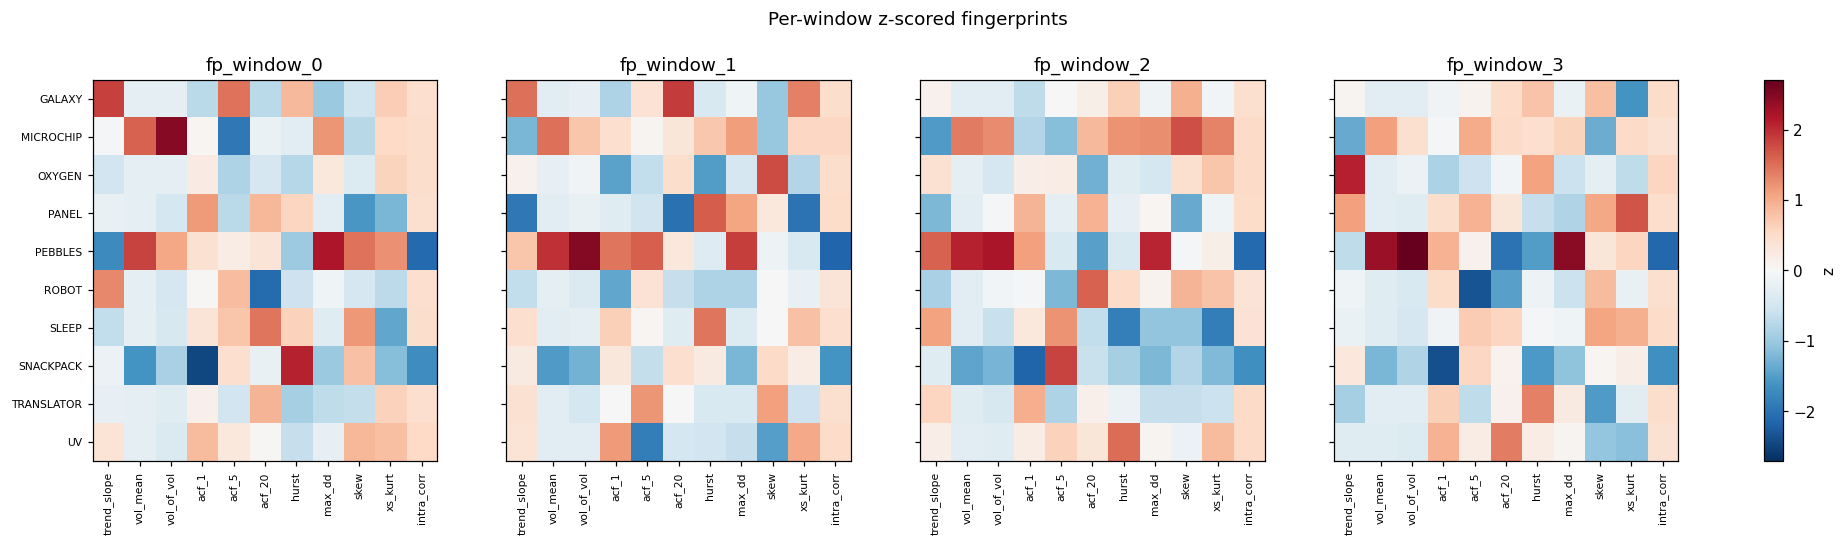

In [13]:
# Per-window fingerprint heatmaps (small multiples)
wkeys = sorted([k for k in res if k.startswith('fp_window_')])
n = len(wkeys)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5), sharey=True)
axes = np.atleast_1d(axes)
vlim = max(np.nanmax(np.abs(ca.zscore_fingerprint(res[k]).values)) for k in wkeys)
for ax, k in zip(axes, wkeys):
    Z = ca.zscore_fingerprint(res[k])
    im = ax.imshow(Z.values, cmap='RdBu_r', vmin=-vlim, vmax=vlim, aspect='auto')
    ax.set_xticks(range(Z.shape[1])); ax.set_xticklabels(Z.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(Z.shape[0])); ax.set_yticklabels(Z.index, fontsize=7)
    ax.set_title(k)
fig.colorbar(im, ax=axes, fraction=0.02, label='z')
fig.suptitle('Per-window z-scored fingerprints', y=1.02)
plt.show()

---
## Phase 3 — Synthesis: archetypes + falsifiable hypotheses

**Archetypes** are obtained by **Ward hierarchical clustering** on the z-scored fingerprint with `k=3`. Ward is chosen because it minimises within-archetype variance, which is exactly the structural-similarity criterion we're after. The dendrogram below shows the merge order; the colored heatmap shows centroid signatures.

**Hypotheses are auto-generated** from the actual numbers in the analysis (`emit_hypotheses` in `cluster_analysis.py`). Each hypothesis lists:

- the **claim** in plain English,
- the **evidence** (the actual numbers backing it),
- a **test** that would falsify it.

Five hypothesis categories are emitted: *outliers* (Phase 2a), *strong full-sample comovement* (2b), *regime-conditional comovement* (2b sign flips), *archetype contrasts* (3), *temporal drift* (2d). The test condition is suggested in operational form so it's runnable with the same dataset (or, where noted, additional analysis).

In [14]:
assign = res['archetype_assignments']
centroids = res['archetype_centroids']
linkage_mat = res['archetype_linkage'].values

print('Archetype assignments (sorted by archetype, then by centroid distance):')
print(assign.round(2).to_string())

Archetype assignments (sorted by archetype, then by centroid distance):
            archetype  dist_to_centroid
category                               
ROBOT               1              1.28
OXYGEN              1              1.71
MICROCHIP           1              2.21
UV                  2              1.51
GALAXY              2              1.56
TRANSLATOR          2              1.63
SLEEP               2              2.09
PANEL               2              2.27
SNACKPACK           2              3.53
PEBBLES             3              0.00


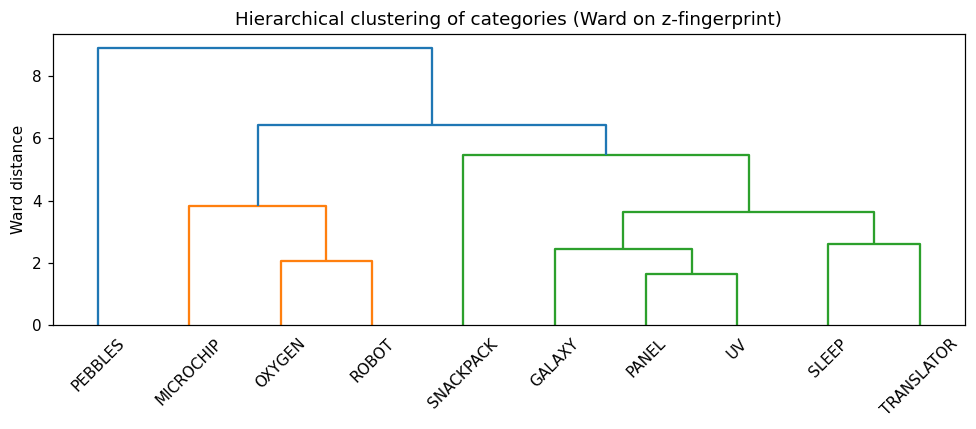

In [15]:
# Dendrogram of the Ward linkage on the z-scored fingerprint.
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(linkage_mat, labels=list(res['fingerprint_zscore'].index),
           leaf_rotation=45, leaf_font_size=10, ax=ax)
ax.set_ylabel('Ward distance')
ax.set_title('Hierarchical clustering of categories (Ward on z-fingerprint)')
plt.tight_layout(); plt.show()

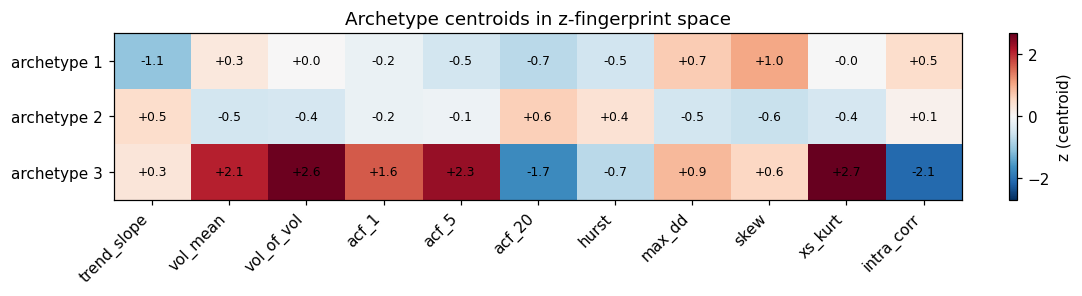

In [16]:
# Centroid signature heatmap — defines what each archetype 'is'.
vlim = float(np.nanmax(np.abs(centroids.values)))
fig, ax = plt.subplots(figsize=(10, 1.0 + 0.6 * len(centroids)))
im = ax.imshow(centroids.values, cmap='RdBu_r', vmin=-vlim, vmax=vlim, aspect='auto')
ax.set_xticks(range(centroids.shape[1])); ax.set_xticklabels(centroids.columns, rotation=45, ha='right')
ax.set_yticks(range(centroids.shape[0])); ax.set_yticklabels([f'archetype {i}' for i in centroids.index])
for i in range(centroids.shape[0]):
    for j in range(centroids.shape[1]):
        ax.text(j, i, f'{centroids.values[i,j]:+.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.04, label='z (centroid)')
ax.set_title('Archetype centroids in z-fingerprint space')
plt.tight_layout(); plt.show()

### Generated hypotheses (data-driven)

Each entry below is **populated from real numbers in this run**. Re-running the pipeline on different data will produce a different set; the *structure* of the claims (outlier, comovement, regime-conditional, archetype contrast, drift) is fixed.

**How to use these.**

- The `claim` is the testable statement.
- The `evidence` is the actual computed statistic that motivates it.
- The `test` is the operational check that would *falsify* it. A claim with no falsification path is not a hypothesis.

**Which are testable with the current data?**

- *Outliers*, *strong comovement*, *archetype contrasts*: directly testable by bootstrap / hold-out (the test fields explain how).
- *Regime-conditional comovement*: testable in-sample with rolling correlation; identifying the *causal* regime variable is the part that needs more data (e.g. macro / event flags) to confirm.
- *Temporal drift*: testable with overlapping windows; for a *causal* drift attribution you'd need an exogenous trigger signal.

In [17]:
for h in meta.get('hypotheses', []):
    print(f"\n[{h['type']}] {h['id']}")
    print('  claim   :', h['claim'])
    print('  evidence:', json.dumps(h['evidence'], indent=12)[12:])
    print('  test    :', h['test'])


[outlier] H_dom_PEBBLES
  claim   : Category PEBBLES structurally dominates across many fingerprint dimensions.
  evidence:   "n_top2": 6,
            "n_bot2": 2,
            "mean_rank": 7.181818181818182,
            "dominance_score": 4
}
  test    : Resample (bootstrap) the per-asset features within the category and re-rank; the dominance score should remain in the top/bottom 2 of the 10 categories in >95% of resamples.

[outlier] H_dom_OXYGEN
  claim   : Category OXYGEN structurally dominates across many fingerprint dimensions.
  evidence:   "n_top2": 2,
            "n_bot2": 0,
            "mean_rank": 6.363636363636363,
            "dominance_score": 2
}
  test    : Resample (bootstrap) the per-asset features within the category and re-rank; the dominance score should remain in the top/bottom 2 of the 10 categories in >95% of resamples.

[outlier] H_dom_SNACKPACK
  claim   : Category SNACKPACK structurally underperforms across many fingerprint dimensions.
  evidence:   "n_top2

---
## Reading the synthesis

Once you've run the pipeline, read this section together with the printout above:

1. **Three archetypes from `centroids`.** Each archetype is a *signature* in the z-feature space. Name it from its 2–3 strongest signed entries (e.g. `+vol_mean, +xs_kurt, -intra_corr` ⇒ "high-vol fat-tailed loose"). The names below are **placeholders to fill in from your run**:
    - Archetype 1: `<dominant features>` ⇒ *<short label>*
    - Archetype 2: `<dominant features>` ⇒ *<short label>*
    - Archetype 3: `<dominant features>` ⇒ *<short label>*
2. **Outlier categories** = those with `dist_to_centroid` substantially larger than the within-archetype median in the `assign` table. Mark them — they don't fit any archetype cleanly.
3. **The 5 emitted hypotheses** above already give you concrete, falsifiable statements grounded in the real numbers. Pick the ones whose `test` you can run with the existing data and execute them next.

Everything is reproducible: re-run `cluster_analysis.py`, get a new `<run_id>` directory, compare against this one with the `archetype_assignments` parquet to see how stable the labelling is.